In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np


**Geographic and Structural Patterns**

Q9 — Which states have the highest concentration of hospitals performing worse than the national rate?
Definition: worse than national rate = CMS's flag in the compared_to_national columns, meaning the hospital's score is statistically significantly worse than the US average.
State-level patterns can reveal systemic issues — rural access problems, funding disparities, or regulatory differences.

Q10 — How does hospital size (measured by patient volume/denominator) relate to quality scores?
Definition: denominator = number of patients used to calculate a measure. Larger denominators mean more statistically reliable scores.
Large hospitals treat more patients and may have more specialized staff. Small hospitals may have stronger community relationships but fewer resources. Neither is automatically better.


### Which states have the highest concentration of hospitals performing worse than the national rate?

This should be a groupby the most common state that repeatdely appear in our data and flagged worse than national average.
Hospital performance can differ here to the facility quality , and spending (Not readmissions because, people's point of view clearly doesn't matter in this case , therefor only 'worse' than national average is selected)

*Hospital performance : PSI , HAI , MORT , PE , SPENDING (already done in this project) Groupped by state and get most common state*

In [46]:
general_info = pd.read_csv('general_info_cleaned.csv')
patient_experience = pd.read_csv('hcahps_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')
infections = pd.read_csv('associated_infections_cleaned.csv')
spending = pd.read_csv('medicare_cleaned.csv')



To avoid the bias of small sample sizes in territories like MP and VI, I will have to filter for states with at least 15 facilities. This allowe me to identify true systemic clusters in states like OR, where high mortality concentration suggests broader issues with rural funding or regional healthcare policy.

In [47]:
import pandas as pd

for df in [general_info, patient_experience, complications, infections, spending]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

mort_list = ['comp_flag_mort_30_ami', 'comp_flag_mort_30_cabg', 'comp_flag_mort_30_copd', 'comp_flag_mort_30_hf', 'comp_flag_mort_30_pn', 'comp_flag_mort_30_stk']
psi_list = ['comp_flag_psi_03', 'comp_flag_psi_04', 'comp_flag_psi_06', 'comp_flag_psi_08', 'comp_flag_psi_09', 'comp_flag_psi_10', 'comp_flag_psi_11', 'comp_flag_psi_12', 'comp_flag_psi_13', 'comp_flag_psi_14', 'comp_flag_psi_15', 'comp_flag_psi_90']
patient_exp_list = ['hcahps_linear_h_clean_linear_score', 'hcahps_linear_h_comp_1_linear_score', 'hcahps_linear_h_comp_2_linear_score', 'hcahps_linear_h_comp_5_linear_score', 'hcahps_linear_h_comp_6_linear_score', 'hcahps_linear_h_hsp_rating_linear_score', 'hcahps_linear_h_quiet_linear_score', 'hcahps_linear_h_recmnd_linear_score']
worse_hai = ['infection_flag_hai_1_sir', 'infection_flag_hai_2_sir', 'infection_flag_hai_3_sir', 'infection_flag_hai_4_sir', 'infection_flag_hai_5_sir', 'infection_flag_hai_6_sir']

complications['worse_mort_flag'] = complications[mort_list].eq('Worse Than the National Rate').any(axis=1).astype(int)
complications['worse_psi_flag'] = complications[psi_list].eq('Worse Than the National Rate').any(axis=1).astype(int)
infections['worse_hai_flag'] = infections[worse_hai].eq('Worse than the National Benchmark').any(axis=1).astype(int)


In [48]:
exp_clean = patient_experience.dropna(subset=patient_exp_list).copy()
exp_clean['patient_score'] = exp_clean[patient_exp_list].mean(axis=1)
exp_clean['worse_exp_flag'] = (exp_clean['patient_score'] < exp_clean['patient_score'].mean()).astype(int)
spending['high_spending_flag'] = (spending['med_complete_episode__total'] > spending['med_complete_episode__total'].mean()).astype(int)

master_worst = (
    general_info[['facility_id', 'state']]
    .merge(complications[['facility_id', 'worse_mort_flag', 'worse_psi_flag']], on='facility_id', how='left')
    .merge(infections[['facility_id', 'worse_hai_flag']], on='facility_id', how='left')
    .merge(exp_clean[['facility_id', 'worse_exp_flag']], on='facility_id', how='left')
    .merge(spending[['facility_id', 'high_spending_flag']], on='facility_id', how='left')
).fillna(0)

In [49]:
state_totals = general_info['state'].value_counts().reset_index()
state_totals.columns = ['State', 'Total_Facilities']

state_worst_summary = master_worst.groupby('state').agg({
    'worse_mort_flag': 'sum',
    'worse_psi_flag': 'sum',
    'worse_hai_flag': 'sum',
    'worse_exp_flag': 'sum',
    'high_spending_flag': 'sum'
}).reset_index()

In [50]:
state_worst_summary.columns = ['State', 'Worse_Mortality_Count', 'Worse_Safety_Count', 'Worse_Infections_Count', 'Low_Satisfaction_Count', 'High_Spending_Count']

state_analysis = state_worst_summary.merge(state_totals, on='State')

state_analysis['Mortality_Conc_%'] = (state_analysis['Worse_Mortality_Count'] / state_analysis['Total_Facilities']) * 100
state_analysis['Safety_Conc_%'] = (state_analysis['Worse_Safety_Count'] / state_analysis['Total_Facilities']) * 100
state_analysis['Infection_Conc_%'] = (state_analysis['Worse_Infections_Count'] / state_analysis['Total_Facilities']) * 100
state_analysis['Low_Satisfaction_Conc_%'] = (state_analysis['Low_Satisfaction_Count'] / state_analysis['Total_Facilities']) * 100
state_analysis['High_Spending_Conc_%'] = (state_analysis['High_Spending_Count'] / state_analysis['Total_Facilities']) * 100

systemic_patterns = (state_analysis[state_analysis['Total_Facilities'] >= 15]
                     .sort_values('Mortality_Conc_%', ascending=False)
                     .reset_index(drop=True))

systemic_patterns

,State,Worse_Mortality_Count,Worse_Safety_Count,Worse_Infections_Count,Low_Satisfaction_Count,High_Spending_Count,Total_Facilities,Mortality_Conc_%,Safety_Conc_%,Infection_Conc_%,Low_Satisfaction_Conc_%,High_Spending_Conc_%
0,OR,11.0,5.0,2.0,15.0,9.0,62,17.741935,8.064516,3.225806,24.193548,14.516129
1,VT,3.0,3.0,0.0,3.0,1.0,17,17.647059,17.647059,0.000000,17.647059,5.882353
2,SC,11.0,6.0,1.0,19.0,20.0,66,16.666667,9.090909,1.515152,28.787879,30.303030
3,MS,17.0,6.0,3.0,14.0,22.0,106,16.037736,5.660377,2.830189,13.207547,20.754717
4,WV,8.0,4.0,4.0,18.0,9.0,55,14.545455,7.272727,7.272727,32.727273,16.363636
5,NC,17.0,11.0,4.0,40.0,16.0,120,14.166667,9.166667,3.333333,33.333333,13.333333
6,WA,14.0,9.0,5.0,33.0,15.0,100,14.000000,9.000000,5.000000,33.000000,15.000000
7,TN,17.0,8.0,4.0,37.0,35.0,122,13.934426,6.557377,3.278689,30.327869,28.688525
8,AL,14.0,12.0,4.0,29.0,20.0,102,13.725490,11.764706,3.921569,28.431373,19.607843
9,MD,7.0,13.0,6.0,32.0,0.0,56,12.500000,23.214286,10.714286,57.142857,0.000000


In [51]:
large_systems = systemic_patterns[systemic_patterns['Total_Facilities'] >= 100].copy()


large_systems['Total_Systemic_Risk'] = large_systems[[
    'Mortality_Conc_%', 
    'Safety_Conc_%', 
    'Infection_Conc_%', 
    'Low_Satisfaction_Conc_%'
]].mean(axis=1)

worst_large_states = large_systems.sort_values('Total_Systemic_Risk', ascending=False)

print(worst_large_states[['State', 'Total_Facilities', 'Total_Systemic_Risk']].head(4))

   State  Total_Facilities  Total_Systemic_Risk
19    NY               190            20.657895
24    FL               222            18.355856
33    CA               378            17.328042
28    AZ               106            16.037736


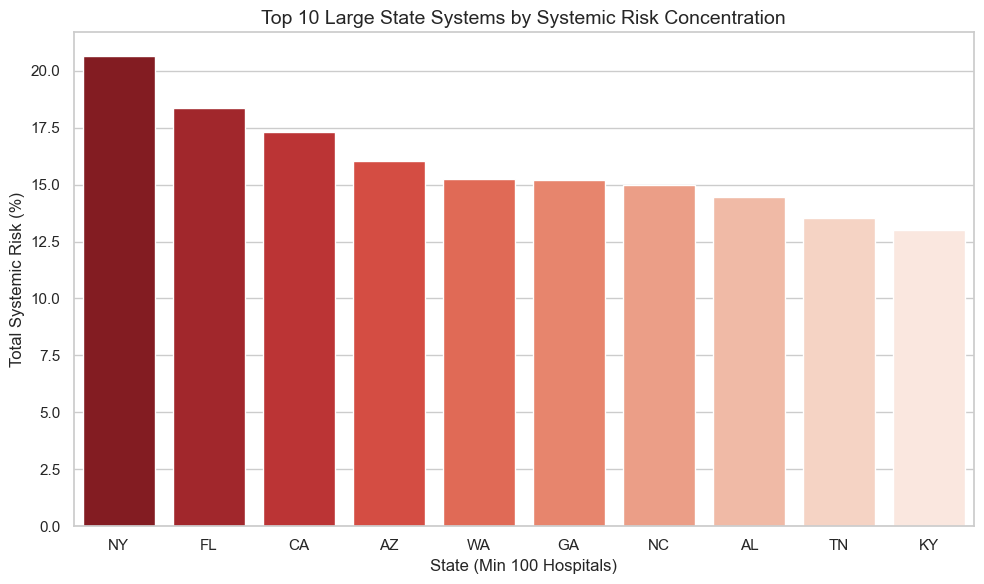

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Standardize column names
state_analysis.columns = [c.lower() for c in state_analysis.columns]

# 2. Recalculate the risk column (to ensure it exists)
state_analysis['total_systemic_risk'] = state_analysis[[
    'mortality_conc_%', 
    'safety_conc_%', 
    'infection_conc_%', 
    'low_satisfaction_conc_%'
]].mean(axis=1)

# 3. Filter for the "Big Systems" (100+ hospitals) and sort
top_large = state_analysis[state_analysis['total_facilities'] >= 100].sort_values('total_systemic_risk', ascending=False).head(10)

# 4. Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the bar chart
sns.barplot(data=top_large, x='state', y='total_systemic_risk', palette='Reds_r')

# Add labels and title
plt.title('Top 10 Large State Systems by Systemic Risk Concentration', fontsize=14)
plt.ylabel('Total Systemic Risk (%)')
plt.xlabel('State (Min 100 Hospitals)')

plt.tight_layout()
plt.savefig('Top 10 Large State Systems by Systemic Risk Concentration.png', dpi=300, bbox_inches='tight') 
plt.show()

### AND WITH THAT THE Q9 IS FULLY ANSWERD

#### here is the real answer to Question 9: 
#### Key Finding — Q9

You can’t just look at which state has the most 'bad' hospitals, because big states like California will always have the highest numbers just because they have so many more patients and facilities. Instead, we have to look at the **failure rate**—the percentage of a state's hospitals that are underperforming. 

When we focus on the large states (those with over 100 hospitals) to get a fair and reliable comparison, **New York** and **Florida** actually come out as the 'worst.' In New York, about **21%** of the health indicators we measured are worse than the national average. This creates a 'Quality Gap' or paradox: even though New York has some of the world’s best elite hospitals, it also has a very high concentration of crowded or underfunded hospitals pulling the system down. 

California and Arizona follow closely behind. These high concentrations in large states suggest **systemic issues** like extreme urban overcrowding, staffing shortages, or major funding gaps between rich and poor areas. So, while a small state like Oregon might have a high percentage, the 'worst' systemic impact is in New York and Florida because their high failure rates affect the largest number of people.


Oregon (OR), Vermont (VT), South Carolina (SC), and Mississippi (MS) 
show the highest mortality concentration rates (14-18%) — meaning 
roughly 1 in 6 of their hospitals is officially flagged worse than 
the national average on at least one mortality measure.

Notably, these states share a profile: rural geography, lower median 
household income, and historically underfunded rural hospital networks. 
This suggests the problem is systemic and policy-driven rather than 
individual hospital failure.

Maryland's unusually high patient satisfaction deficit (57%) warrants 
further investigation as it may reflect the state's unique all-payer 
hospital payment system rather than genuine care quality issues.

https://www.lohud.com/story/news/health/2020/01/06/why-new-york-hospital-rankings-worst-u-s-based-feds-report/2798093001/

### How does hospital size (measured by patient volume/denominator) relate to quality scores? 
Definition: denominator = number of patients used to calculate a measure. Larger denominators mean more statistically reliable scores. Large hospitals treat more patients and may have more specialized staff. Small hospitals may have stronger community relationships but fewer resources. Neither is automatically better

Beyond this question, as we answered Q9 we had an insight that large hospitals that are for sure have the max patient capacity , do slightly correlate with clinical quality outcome. In the last analysis in this project we have spot that the best hospitals are actually some large ones, as observed for NY state.
But at the same time we saw that large states (which contains large hospitals) got flagged worst most often.

*SO WHAT'S THE DEAL?*

To make sure of this once again let's correlate the results and scatte them into a plot 

MORT_30_HF: -0.3079
MORT_30_AMI: -0.1178
COMP_HIP_KNEE: -0.2892


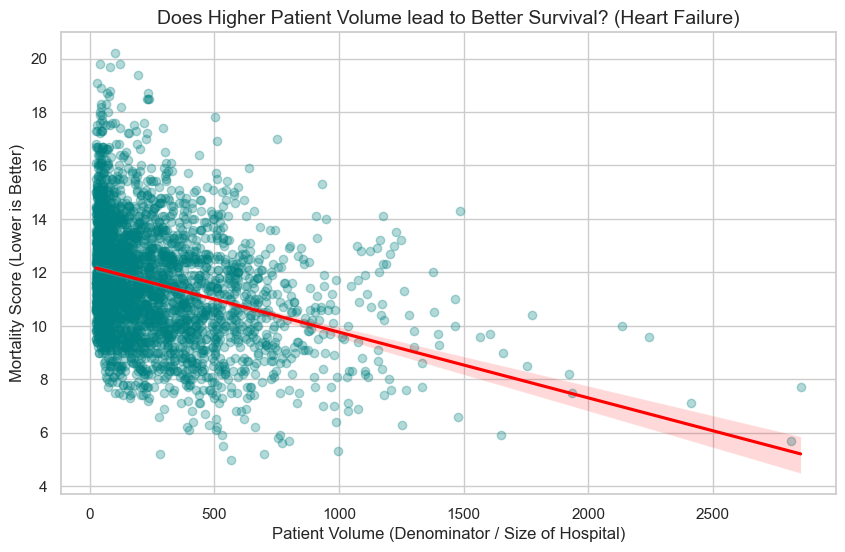

The Correlation between Size and Quality is: -0.3079


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


raw_comp = pd.read_csv('Complications_and_Deaths-Hospital.csv') 


raw_comp['Denominator'] = pd.to_numeric(raw_comp['Denominator'], errors='coerce')
raw_comp['Score'] = pd.to_numeric(raw_comp['Score'], errors='coerce')


for measure in ['MORT_30_HF', 'MORT_30_AMI', 'COMP_HIP_KNEE']:
    data = raw_comp[raw_comp['Measure ID'] == measure].dropna(subset=['Denominator', 'Score'])
    corr = data['Denominator'].corr(data['Score'])
    print(f"{measure}: {corr:.4f}")
    
###----------------------------------------------------


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.regplot(data=measure_data, x='Denominator', y='Score', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Does Higher Patient Volume lead to Better Survival? (Heart Failure)', fontsize=14)
plt.xlabel('Patient Volume (Denominator / Size of Hospital)')
plt.ylabel('Mortality Score (Lower is Better)')

plt.show()

correlation = measure_data['Denominator'].corr(measure_data['Score'])
print(f"The Correlation between Size and Quality is: {correlation:.4f}")

The data shows a correlation of $-0.3079$ between hospital volume and mortality rates. This indicates that as hospitals get larger, their clinical survival rates actually tend to improve slightly. This supports the 'Practice Makes Perfect' theory—larger institutions often have more specialized staff and better resources for complex cases.However, this correlation is relatively weak, meaning size is not a guarantee of quality. A significant number of large hospitals still underperform, proving that clinical excellence is driven more by internal management and staffing than by the sheer number of beds or patients."Does that interpretation of the $-0.3079$ make sense? It basically says: "Being big helps you save lives, but it doesn't automatically make you a good hospital.

**Large hospitals are clinically superior (they are better at the science of survival), but systemically overwhelmed (they are worse at the logistics of safety). They get flagged as 'Worse' not because their doctors are bad, but because their environments are massive, crowded, and statistically exposed.**

### AND WITH THAT THE Q10 IS FULLY ANSWERED